In [19]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


检测到缓存文件，正在加载...
绘图完成: IDP_SOLV.png


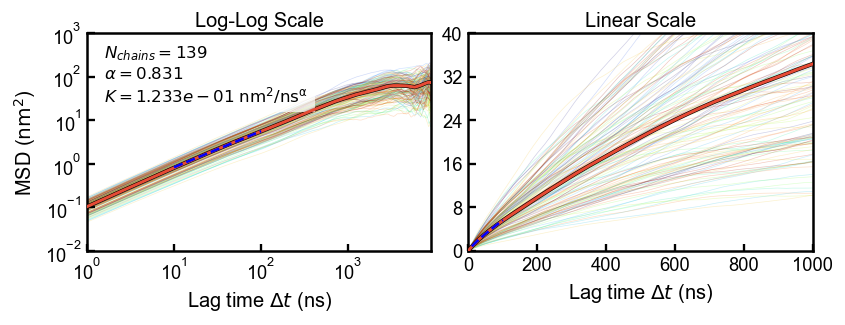

In [20]:
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, NullLocator
from scipy.stats import linregress
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
import sys
import os
import gc
from concurrent.futures import ProcessPoolExecutor

# ===================== 用户参数设置 =====================
REPLICATES = [
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc'),
]

PARAMS = {
    'RESIDUES_PER_CHAIN': 140,
    'BB_SELECTION_STR': 'name BB',
    'ANALYSIS_CHAIN_RANGE': (0, None), 
    'START_FRAME': 10000,
    'END_FRAME': -1,
    'STRIDE': 1,
    'CLUSTER_DIST_CUTOFF': 8.0,
    'MAX_LAG_RATIO': 0.9,
    'FIT_START_NS': 10.0,
    'FIT_END_NS': 100.0,
}

COLOR_MAP = 'turbo'
FIG_PRESET = 'double_short'
OUTPUT_PLOT = 'IDP_SOLV.png'
CACHE_MSD = 'IDP_SOLV_msd_matrix.npy'
CACHE_TIME = 'IDP_SOLV_time_ns.npy'
A2_TO_NM2 = 0.01

# ===================== 核心计算逻辑 =====================

def process_single_replicate(args):
    rep_id, top_file, traj_file, p = args
    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as e:
        return None, f"Error: {e}"

    protein = u.select_atoms('protein')
    n_chains = len(protein.residues) // p['RESIDUES_PER_CHAIN']
    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(p['BB_SELECTION_STR'])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[p['START_FRAME']:p['END_FRAME']:p['STRIDE']]
    n_frames = len(traj_slice)
    
    all_coms = np.zeros((n_frames, n_chains, 3), dtype=np.float32)
    start_c, end_c = p['ANALYSIS_CHAIN_RANGE']
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    # 轨迹处理
    for i, ts in enumerate(traj_slice):
        # 向量化 COM 计算
        all_coms[i] = protein.positions.reshape(n_chains, -1, 3).mean(axis=1)
        
        # 团簇分析 (Scipy 高效版)
        pairs = capped_distance(bb_atoms.positions, bb_atoms.positions, 
                                max_cutoff=p['CLUSTER_DIST_CUTOFF'], 
                                box=ts.dimensions, return_distances=False)
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]
        
        adj = csr_matrix((np.ones(len(c_pairs)), (c_pairs[:,0], c_pairs[:,1])), shape=(n_chains, n_chains))
        n_comp, labels = connected_components(adj, directed=False)
        
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= (labels == max_label)
        else:
            valid_mask[:] = False; break

    final_indices = np.where(valid_mask)[0]
    num_valid = len(final_indices)
    
    if num_valid == 0:
        return None, "No chains remained."

    # MSD 向量化计算
    valid_coms = all_coms[:, final_indices, :]
    max_lag = int(n_frames * p['MAX_LAG_RATIO'])
    msd_matrix = np.zeros((max_lag, num_valid))
    for lag in range(1, max_lag + 1):
        diff = valid_coms[lag:] - valid_coms[:-lag]
        msd_matrix[lag-1] = np.mean(np.sum(diff**2, axis=2), axis=0)

    time_ns = (np.arange(1, max_lag + 1) * u.trajectory.dt * p['STRIDE']) / 1000.0
    return {'msd': msd_matrix, 'time': time_ns, 'count': num_valid, 'file': os.path.basename(traj_file)}, None

def main():
    # --- 1. 数据获取 ---
    if os.path.exists(CACHE_MSD) and os.path.exists(CACHE_TIME):
        print(f"检测到缓存文件，正在加载...")
        combined_msd = np.load(CACHE_MSD)
        ref_time_ns = np.load(CACHE_TIME)
    else:
        print(f"开始并行计算 {len(REPLICATES)} 个副本...")
        tasks = [(i, r[0], r[1], PARAMS) for i, r in enumerate(REPLICATES)]
        
        with ProcessPoolExecutor(max_workers=len(REPLICATES)) as executor:
            results = list(executor.map(process_single_replicate, tasks))
        
        # 打印统计表格
        print("\n" + "="*70)
        print(f"{'副本索引':<10} | {'轨迹文件名':<35} | {'最终分析链数':<12}")
        print("-" * 70)
        
        valid_msds = []
        ref_time_ns = None
        for i, (res, err) in enumerate(results):
            if res:
                print(f"{i:<10} | {res['file']:<35} | {res['count']:<12}")
                if ref_time_ns is None: ref_time_ns = res['time']
                valid_msds.append(res['msd'])
            else:
                print(f"{i:<10} | {'Error or No Data':<35} | 0")
        
        if not valid_msds:
            print("错误：无有效数据。"); return
            
        combined_msd = np.hstack(valid_msds)
        print("="*70)
        print(f"总计分析链数: {combined_msd.shape[1]}\n")
        
        np.save(CACHE_MSD, combined_msd)
        np.save(CACHE_TIME, ref_time_ns)

    # --- 2. 拟合逻辑 ---
    grand_avg = np.mean(combined_msd, axis=1)
    grand_avg_nm2 = grand_avg * A2_TO_NM2
    fit_idx = (ref_time_ns >= PARAMS['FIT_START_NS']) & (ref_time_ns <= PARAMS['FIT_END_NS'])
    ln_t = np.log(ref_time_ns[fit_idx])
    ln_msd = np.log(grand_avg_nm2[fit_idx])
    res_fit = linregress(ln_t, ln_msd)
    alpha, K_ns = res_fit.slope, np.exp(res_fit.intercept)

    # --- 3. 绘图 (Log-Log 和 Linear 左右两张图) ---
    fig, axes = new_subplots(1, 2, preset=FIG_PRESET)
    fig.subplots_adjust(wspace=0.30)
    
    ax_log = axes[0] # 左边：对数坐标
    ax_lin = axes[1] # 右边：线性坐标
    
    n_chains = combined_msd.shape[1]
    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))
    fit_t_plot = ref_time_ns[fit_idx] # 拟合的时间段数据

    # ========== 左图：Log-Log Scale ==========
    ax_log.set_title("Log-Log Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线
    for i in range(n_chains):
        ax_log.loglog(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线
    ax_log.loglog(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit {PARAMS["FIT_START_NS"]}-{PARAMS["FIT_END_NS"]}ns')

    # 4. 文本框
    eq_text = (f"$N_{{chains}} = {n_chains}$\n"
               f"$\\alpha = {alpha:.3f}$\n"
               f"$K = {K_ns:.3e}$" + r" $\mathrm{nm^2/ns^\alpha}$")
    ax_log.text(0.05, 0.95, eq_text, transform=ax_log.transAxes, verticalalignment='top', 
            fontsize=mpl.rcParams['legend.fontsize'], bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 5. 标签与格式
    ax_log.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_xlim(ref_time_ns[0], ref_time_ns[-1])
    ax_log.set_ylim(1e-2, 1e3)
    ax_log.grid(False)
    ax_log.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.xaxis.set_minor_locator(NullLocator())
    ax_log.yaxis.set_minor_locator(NullLocator())
    ax_log.tick_params(top=False, right=False)

    # ========== 右图：Linear Scale ==========
    ax_lin.set_title("Linear Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线 (使用 plot 而不是 loglog)
    for i in range(n_chains):
        ax_lin.plot(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线 (可选，用于对比)
    # 即使在线性图上，幂律也是曲线，画出来很有参考价值
    ax_lin.plot(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit')

    # 4. 标签与格式
    ax_lin.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    # Y轴标签可以简化，或者不写单位只写MSD
    ax_lin.set_ylabel("")
    
    # 线性图的范围：X轴保持一致，Y轴自动缩放或从0开始
    ax_lin.set_xlim(0, 1000)
    ax_lin.set_ylim(0, 40)
    ax_lin.set_yticks([0, 20, 40])
    ax_lin.grid(False)
    ax_lin.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.minorticks_off()
    ax_lin.tick_params(top=False, right=False)
    # ax_lin.legend(frameon=False) # 如果需要图例可以取消注释

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)
    savefig_pub(fig, OUTPUT_PLOT, tight=True)
    print(f"绘图完成: {OUTPUT_PLOT}")
    plt.show()

if __name__ == "__main__":
    main()


In [21]:
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, NullLocator
from scipy.stats import linregress
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
import sys
import os
import gc
from concurrent.futures import ProcessPoolExecutor

# ===================== 用户参数设置 =====================
REPLICATES = [
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc'),
]

PARAMS = {
    'RESIDUES_PER_CHAIN': 140,
    'BB_SELECTION_STR': 'name BB',
    'ANALYSIS_CHAIN_RANGE': (0, None), 
    'START_FRAME': 10000,
    'END_FRAME': -1,
    'STRIDE': 1,
    'CLUSTER_DIST_CUTOFF': 8.0,
    'MAX_LAG_RATIO': 0.9,
    'FIT_START_NS': 10.0,
    'FIT_END_NS': 100.0,
}

COLOR_MAP = 'turbo'
FIG_PRESET = 'double_short'
OUTPUT_PLOT = 'Helix_SOLV.png'
CACHE_MSD = 'Helix_SOLV_msd_matrix.npy'
CACHE_TIME = 'Helix_SOLV_time_ns.npy'
A2_TO_NM2 = 0.01

# ===================== 核心计算逻辑 =====================

def process_single_replicate(args):
    rep_id, top_file, traj_file, p = args
    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as e:
        return None, f"Error: {e}"

    protein = u.select_atoms('protein')
    n_chains = len(protein.residues) // p['RESIDUES_PER_CHAIN']
    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(p['BB_SELECTION_STR'])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[p['START_FRAME']:p['END_FRAME']:p['STRIDE']]
    n_frames = len(traj_slice)
    
    all_coms = np.zeros((n_frames, n_chains, 3), dtype=np.float32)
    start_c, end_c = p['ANALYSIS_CHAIN_RANGE']
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    # 轨迹处理
    for i, ts in enumerate(traj_slice):
        # 向量化 COM 计算
        all_coms[i] = protein.positions.reshape(n_chains, -1, 3).mean(axis=1)
        
        # 团簇分析 (Scipy 高效版)
        pairs = capped_distance(bb_atoms.positions, bb_atoms.positions, 
                                max_cutoff=p['CLUSTER_DIST_CUTOFF'], 
                                box=ts.dimensions, return_distances=False)
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]
        
        adj = csr_matrix((np.ones(len(c_pairs)), (c_pairs[:,0], c_pairs[:,1])), shape=(n_chains, n_chains))
        n_comp, labels = connected_components(adj, directed=False)
        
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= (labels == max_label)
        else:
            valid_mask[:] = False; break

    final_indices = np.where(valid_mask)[0]
    num_valid = len(final_indices)
    
    if num_valid == 0:
        return None, "No chains remained."

    # MSD 向量化计算
    valid_coms = all_coms[:, final_indices, :]
    max_lag = int(n_frames * p['MAX_LAG_RATIO'])
    msd_matrix = np.zeros((max_lag, num_valid))
    for lag in range(1, max_lag + 1):
        diff = valid_coms[lag:] - valid_coms[:-lag]
        msd_matrix[lag-1] = np.mean(np.sum(diff**2, axis=2), axis=0)

    time_ns = (np.arange(1, max_lag + 1) * u.trajectory.dt * p['STRIDE']) / 1000.0
    return {'msd': msd_matrix, 'time': time_ns, 'count': num_valid, 'file': os.path.basename(traj_file)}, None

def main():
    # --- 1. 数据获取 ---
    if os.path.exists(CACHE_MSD) and os.path.exists(CACHE_TIME):
        print(f"检测到缓存文件，正在加载...")
        combined_msd = np.load(CACHE_MSD)
        ref_time_ns = np.load(CACHE_TIME)
    else:
        print(f"开始并行计算 {len(REPLICATES)} 个副本...")
        tasks = [(i, r[0], r[1], PARAMS) for i, r in enumerate(REPLICATES)]
        
        with ProcessPoolExecutor(max_workers=len(REPLICATES)) as executor:
            results = list(executor.map(process_single_replicate, tasks))
        
        # 打印统计表格
        print("\n" + "="*70)
        print(f"{'副本索引':<10} | {'轨迹文件名':<35} | {'最终分析链数':<12}")
        print("-" * 70)
        
        valid_msds = []
        ref_time_ns = None
        for i, (res, err) in enumerate(results):
            if res:
                print(f"{i:<10} | {res['file']:<35} | {res['count']:<12}")
                if ref_time_ns is None: ref_time_ns = res['time']
                valid_msds.append(res['msd'])
            else:
                print(f"{i:<10} | {'Error or No Data':<35} | 0")
        
        if not valid_msds:
            print("错误：无有效数据。"); return
            
        combined_msd = np.hstack(valid_msds)
        print("="*70)
        print(f"总计分析链数: {combined_msd.shape[1]}\n")
        
        np.save(CACHE_MSD, combined_msd)
        np.save(CACHE_TIME, ref_time_ns)

    # --- 2. 拟合逻辑 ---
    grand_avg = np.mean(combined_msd, axis=1)
    grand_avg_nm2 = grand_avg * A2_TO_NM2
    fit_idx = (ref_time_ns >= PARAMS['FIT_START_NS']) & (ref_time_ns <= PARAMS['FIT_END_NS'])
    ln_t = np.log(ref_time_ns[fit_idx])
    ln_msd = np.log(grand_avg_nm2[fit_idx])
    res_fit = linregress(ln_t, ln_msd)
    alpha, K_ns = res_fit.slope, np.exp(res_fit.intercept)

    # --- 3. 绘图 (Log-Log 和 Linear 左右两张图) ---
    fig, axes = new_subplots(1, 2, preset=FIG_PRESET)
    fig.subplots_adjust(wspace=0.30)
    
    ax_log = axes[0] # 左边：对数坐标
    ax_lin = axes[1] # 右边：线性坐标
    
    n_chains = combined_msd.shape[1]
    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))
    fit_t_plot = ref_time_ns[fit_idx] # 拟合的时间段数据

    # ========== 左图：Log-Log Scale ==========
    ax_log.set_title("Log-Log Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线
    for i in range(n_chains):
        ax_log.loglog(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线
    ax_log.loglog(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit {PARAMS["FIT_START_NS"]}-{PARAMS["FIT_END_NS"]}ns')

    # 4. 文本框
    eq_text = (f"$N_{{chains}} = {n_chains}$\n"
               f"$\\alpha = {alpha:.3f}$\n"
               f"$K = {K_ns:.3e}$" + r" $\mathrm{nm^2/ns^\alpha}$")
    ax_log.text(0.05, 0.95, eq_text, transform=ax_log.transAxes, verticalalignment='top', 
            fontsize=mpl.rcParams['legend.fontsize'], bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 5. 标签与格式
    ax_log.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_xlim(ref_time_ns[0], ref_time_ns[-1])
    ax_log.set_ylim(1e-2, 1e3)
    ax_log.grid(False)
    ax_log.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.xaxis.set_minor_locator(NullLocator())
    ax_log.yaxis.set_minor_locator(NullLocator())
    ax_log.tick_params(top=False, right=False)

    # ========== 右图：Linear Scale ==========
    ax_lin.set_title("Linear Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线 (使用 plot 而不是 loglog)
    for i in range(n_chains):
        ax_lin.plot(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线 (可选，用于对比)
    # 即使在线性图上，幂律也是曲线，画出来很有参考价值
    ax_lin.plot(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit')

    # 4. 标签与格式
    ax_lin.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    # Y轴标签可以简化，或者不写单位只写MSD
    ax_lin.set_ylabel("")
    
    # 线性图的范围：X轴保持一致，Y轴自动缩放或从0开始
    ax_lin.set_xlim(0, 1000)
    ax_lin.set_ylim(0, 40)
    ax_lin.set_yticks([0, 20, 40])
    ax_lin.grid(False)
    ax_lin.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.minorticks_off()
    ax_lin.tick_params(top=False, right=False)
    # ax_lin.legend(frameon=False) # 如果需要图例可以取消注释

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)
    savefig_pub(fig, OUTPUT_PLOT, tight=True)
    print(f"绘图完成: {OUTPUT_PLOT}")
    plt.show()

# if __name__ == "__main__":
#     main()


检测到缓存文件，正在加载...
绘图完成: IDP_MEM.png


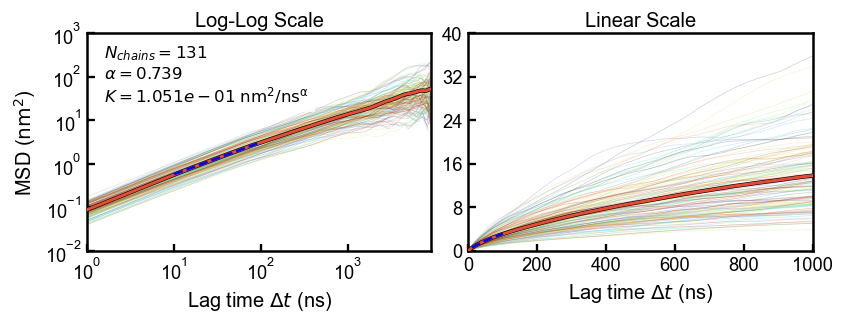

In [22]:
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, NullLocator
from scipy.stats import linregress
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
import sys
import os
import gc
from concurrent.futures import ProcessPoolExecutor

# ===================== 用户参数设置 =====================
REPLICATES = [
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/clus_centered.xtc'),
]

PARAMS = {
    'RESIDUES_PER_CHAIN': 140,
    'BB_SELECTION_STR': 'name BB',
    'ANALYSIS_CHAIN_RANGE': (0, None), 
    'START_FRAME': 0,
    'END_FRAME': -1,
    'STRIDE': 1,
    'CLUSTER_DIST_CUTOFF': 8.0,
    'MAX_LAG_RATIO': 0.9,
    'FIT_START_NS': 10.0,
    'FIT_END_NS': 100.0,
}

COLOR_MAP = 'turbo'
FIG_PRESET = 'double_short'
OUTPUT_PLOT = 'IDP_MEM.png'
CACHE_MSD = 'IDP_MEM_msd_matrix.npy'
CACHE_TIME = 'IDP_MEM_time_ns.npy'
A2_TO_NM2 = 0.01

# ===================== 核心计算逻辑 =====================

def process_single_replicate(args):
    rep_id, top_file, traj_file, p = args
    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as e:
        return None, f"Error: {e}"

    protein = u.select_atoms('protein')
    n_chains = len(protein.residues) // p['RESIDUES_PER_CHAIN']
    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(p['BB_SELECTION_STR'])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[p['START_FRAME']:p['END_FRAME']:p['STRIDE']]
    n_frames = len(traj_slice)
    
    all_coms = np.zeros((n_frames, n_chains, 3), dtype=np.float32)
    start_c, end_c = p['ANALYSIS_CHAIN_RANGE']
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    # 轨迹处理
    for i, ts in enumerate(traj_slice):
        # 向量化 COM 计算
        all_coms[i] = protein.positions.reshape(n_chains, -1, 3).mean(axis=1)
        
        # 团簇分析 (Scipy 高效版)
        pairs = capped_distance(bb_atoms.positions, bb_atoms.positions, 
                                max_cutoff=p['CLUSTER_DIST_CUTOFF'], 
                                box=ts.dimensions, return_distances=False)
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]
        
        adj = csr_matrix((np.ones(len(c_pairs)), (c_pairs[:,0], c_pairs[:,1])), shape=(n_chains, n_chains))
        n_comp, labels = connected_components(adj, directed=False)
        
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= (labels == max_label)
        else:
            valid_mask[:] = False; break

    final_indices = np.where(valid_mask)[0]
    num_valid = len(final_indices)
    
    if num_valid == 0:
        return None, "No chains remained."

    # MSD 向量化计算
    valid_coms = all_coms[:, final_indices, :]
    max_lag = int(n_frames * p['MAX_LAG_RATIO'])
    msd_matrix = np.zeros((max_lag, num_valid))
    for lag in range(1, max_lag + 1):
        diff = valid_coms[lag:] - valid_coms[:-lag]
        msd_matrix[lag-1] = np.mean(np.sum(diff**2, axis=2), axis=0)

    time_ns = (np.arange(1, max_lag + 1) * u.trajectory.dt * p['STRIDE']) / 1000.0
    return {'msd': msd_matrix, 'time': time_ns, 'count': num_valid, 'file': os.path.basename(traj_file)}, None

def main():
    # --- 1. 数据获取 ---
    if os.path.exists(CACHE_MSD) and os.path.exists(CACHE_TIME):
        print(f"检测到缓存文件，正在加载...")
        combined_msd = np.load(CACHE_MSD)
        ref_time_ns = np.load(CACHE_TIME)
    else:
        print(f"开始并行计算 {len(REPLICATES)} 个副本...")
        tasks = [(i, r[0], r[1], PARAMS) for i, r in enumerate(REPLICATES)]
        
        with ProcessPoolExecutor(max_workers=len(REPLICATES)) as executor:
            results = list(executor.map(process_single_replicate, tasks))
        
        # 打印统计表格
        print("\n" + "="*70)
        print(f"{'副本索引':<10} | {'轨迹文件名':<35} | {'最终分析链数':<12}")
        print("-" * 70)
        
        valid_msds = []
        ref_time_ns = None
        for i, (res, err) in enumerate(results):
            if res:
                print(f"{i:<10} | {res['file']:<35} | {res['count']:<12}")
                if ref_time_ns is None: ref_time_ns = res['time']
                valid_msds.append(res['msd'])
            else:
                print(f"{i:<10} | {'Error or No Data':<35} | 0")
        
        if not valid_msds:
            print("错误：无有效数据。"); return
            
        combined_msd = np.hstack(valid_msds)
        print("="*70)
        print(f"总计分析链数: {combined_msd.shape[1]}\n")
        
        np.save(CACHE_MSD, combined_msd)
        np.save(CACHE_TIME, ref_time_ns)

    # --- 2. 拟合逻辑 ---
    grand_avg = np.mean(combined_msd, axis=1)
    grand_avg_nm2 = grand_avg * A2_TO_NM2
    fit_idx = (ref_time_ns >= PARAMS['FIT_START_NS']) & (ref_time_ns <= PARAMS['FIT_END_NS'])
    ln_t = np.log(ref_time_ns[fit_idx])
    ln_msd = np.log(grand_avg_nm2[fit_idx])
    res_fit = linregress(ln_t, ln_msd)
    alpha, K_ns = res_fit.slope, np.exp(res_fit.intercept)

    # --- 3. 绘图 (Log-Log 和 Linear 左右两张图) ---
    fig, axes = new_subplots(1, 2, preset=FIG_PRESET)
    fig.subplots_adjust(wspace=0.30)
    
    ax_log = axes[0] # 左边：对数坐标
    ax_lin = axes[1] # 右边：线性坐标
    
    n_chains = combined_msd.shape[1]
    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))
    fit_t_plot = ref_time_ns[fit_idx] # 拟合的时间段数据

    # ========== 左图：Log-Log Scale ==========
    ax_log.set_title("Log-Log Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线
    for i in range(n_chains):
        ax_log.loglog(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线
    ax_log.loglog(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit {PARAMS["FIT_START_NS"]}-{PARAMS["FIT_END_NS"]}ns')

    # 4. 文本框
    eq_text = (f"$N_{{chains}} = {n_chains}$\n"
               f"$\\alpha = {alpha:.3f}$\n"
               f"$K = {K_ns:.3e}$" + r" $\mathrm{nm^2/ns^\alpha}$")
    ax_log.text(0.05, 0.95, eq_text, transform=ax_log.transAxes, verticalalignment='top', 
            fontsize=mpl.rcParams['legend.fontsize'], bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 5. 标签与格式
    ax_log.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_xlim(ref_time_ns[0], ref_time_ns[-1])
    ax_log.set_ylim(1e-2, 1e3)
    ax_log.grid(False)
    ax_log.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.xaxis.set_minor_locator(NullLocator())
    ax_log.yaxis.set_minor_locator(NullLocator())
    ax_log.tick_params(top=False, right=False)

    # ========== 右图：Linear Scale ==========
    ax_lin.set_title("Linear Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线 (使用 plot 而不是 loglog)
    for i in range(n_chains):
        ax_lin.plot(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线 (可选，用于对比)
    # 即使在线性图上，幂律也是曲线，画出来很有参考价值
    ax_lin.plot(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit')

    # 4. 标签与格式
    ax_lin.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    # Y轴标签可以简化，或者不写单位只写MSD
    ax_lin.set_ylabel("")
    
    # 线性图的范围：X轴保持一致，Y轴自动缩放或从0开始
    ax_lin.set_xlim(0, 1000)
    ax_lin.set_ylim(0, 40)
    ax_lin.set_yticks([0, 20, 40])
    ax_lin.grid(False)
    ax_lin.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.minorticks_off()
    ax_lin.tick_params(top=False, right=False)
    # ax_lin.legend(frameon=False) # 如果需要图例可以取消注释

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)
    savefig_pub(fig, OUTPUT_PLOT, tight=True)
    print(f"绘图完成: {OUTPUT_PLOT}")
    plt.show()

if __name__ == "__main__":
    main()


检测到缓存文件，正在加载...
绘图完成: Helix_MEM.png


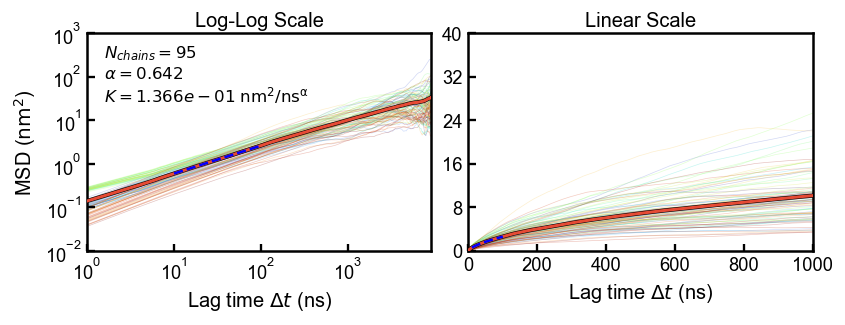

In [23]:
import MDAnalysis as mda
from MDAnalysis.lib.distances import capped_distance
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, NullLocator
from scipy.stats import linregress
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
import sys
import os
import gc
from concurrent.futures import ProcessPoolExecutor

# ===================== 用户参数设置 =====================
REPLICATES = [
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/clus_centered.xtc'),
    ('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/pbc.tpr', 
     '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/clus_centered.xtc'),
]

PARAMS = {
    'RESIDUES_PER_CHAIN': 140,
    'BB_SELECTION_STR': 'name BB',
    'ANALYSIS_CHAIN_RANGE': (-40, None), 
    'START_FRAME': 10000,
    'END_FRAME': -1,
    'STRIDE': 1,
    'CLUSTER_DIST_CUTOFF': 8.0,
    'MAX_LAG_RATIO': 0.9,
    'FIT_START_NS': 10.0,
    'FIT_END_NS': 100.0,
}

COLOR_MAP = 'turbo'
FIG_PRESET = 'double_short'
OUTPUT_PLOT = 'Helix_MEM.png'
CACHE_MSD = 'Helix_MEM_msd_matrix.npy'
CACHE_TIME = 'Helix_MEM_time_ns.npy'
A2_TO_NM2 = 0.01

# ===================== 核心计算逻辑 =====================

def process_single_replicate(args):
    rep_id, top_file, traj_file, p = args
    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as e:
        return None, f"Error: {e}"

    protein = u.select_atoms('protein')
    n_chains = len(protein.residues) // p['RESIDUES_PER_CHAIN']
    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(p['BB_SELECTION_STR'])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[p['START_FRAME']:p['END_FRAME']:p['STRIDE']]
    n_frames = len(traj_slice)
    
    all_coms = np.zeros((n_frames, n_chains, 3), dtype=np.float32)
    start_c, end_c = p['ANALYSIS_CHAIN_RANGE']
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    # 轨迹处理
    for i, ts in enumerate(traj_slice):
        # 向量化 COM 计算
        all_coms[i] = protein.positions.reshape(n_chains, -1, 3).mean(axis=1)
        
        # 团簇分析 (Scipy 高效版)
        pairs = capped_distance(bb_atoms.positions, bb_atoms.positions, 
                                max_cutoff=p['CLUSTER_DIST_CUTOFF'], 
                                box=ts.dimensions, return_distances=False)
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]
        
        adj = csr_matrix((np.ones(len(c_pairs)), (c_pairs[:,0], c_pairs[:,1])), shape=(n_chains, n_chains))
        n_comp, labels = connected_components(adj, directed=False)
        
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= (labels == max_label)
        else:
            valid_mask[:] = False; break

    final_indices = np.where(valid_mask)[0]
    num_valid = len(final_indices)
    
    if num_valid == 0:
        return None, "No chains remained."

    # MSD 向量化计算
    valid_coms = all_coms[:, final_indices, :]
    max_lag = int(n_frames * p['MAX_LAG_RATIO'])
    msd_matrix = np.zeros((max_lag, num_valid))
    for lag in range(1, max_lag + 1):
        diff = valid_coms[lag:] - valid_coms[:-lag]
        msd_matrix[lag-1] = np.mean(np.sum(diff**2, axis=2), axis=0)

    time_ns = (np.arange(1, max_lag + 1) * u.trajectory.dt * p['STRIDE']) / 1000.0
    return {'msd': msd_matrix, 'time': time_ns, 'count': num_valid, 'file': os.path.basename(traj_file)}, None

def main():
    # --- 1. 数据获取 ---
    if os.path.exists(CACHE_MSD) and os.path.exists(CACHE_TIME):
        print(f"检测到缓存文件，正在加载...")
        combined_msd = np.load(CACHE_MSD)
        ref_time_ns = np.load(CACHE_TIME)
    else:
        print(f"开始并行计算 {len(REPLICATES)} 个副本...")
        tasks = [(i, r[0], r[1], PARAMS) for i, r in enumerate(REPLICATES)]
        
        with ProcessPoolExecutor(max_workers=len(REPLICATES)) as executor:
            results = list(executor.map(process_single_replicate, tasks))
        
        # 打印统计表格
        print("\n" + "="*70)
        print(f"{'副本索引':<10} | {'轨迹文件名':<35} | {'最终分析链数':<12}")
        print("-" * 70)
        
        valid_msds = []
        ref_time_ns = None
        for i, (res, err) in enumerate(results):
            if res:
                print(f"{i:<10} | {res['file']:<35} | {res['count']:<12}")
                if ref_time_ns is None: ref_time_ns = res['time']
                valid_msds.append(res['msd'])
            else:
                print(f"{i:<10} | {'Error or No Data':<35} | 0")
        
        if not valid_msds:
            print("错误：无有效数据。"); return
            
        combined_msd = np.hstack(valid_msds)
        print("="*70)
        print(f"总计分析链数: {combined_msd.shape[1]}\n")
        
        np.save(CACHE_MSD, combined_msd)
        np.save(CACHE_TIME, ref_time_ns)

    # --- 2. 拟合逻辑 ---
    grand_avg = np.mean(combined_msd, axis=1)
    grand_avg_nm2 = grand_avg * A2_TO_NM2
    fit_idx = (ref_time_ns >= PARAMS['FIT_START_NS']) & (ref_time_ns <= PARAMS['FIT_END_NS'])
    ln_t = np.log(ref_time_ns[fit_idx])
    ln_msd = np.log(grand_avg_nm2[fit_idx])
    res_fit = linregress(ln_t, ln_msd)
    alpha, K_ns = res_fit.slope, np.exp(res_fit.intercept)

    # --- 3. 绘图 (Log-Log 和 Linear 左右两张图) ---
    fig, axes = new_subplots(1, 2, preset=FIG_PRESET)
    fig.subplots_adjust(wspace=0.30)
    
    ax_log = axes[0] # 左边：对数坐标
    ax_lin = axes[1] # 右边：线性坐标
    
    n_chains = combined_msd.shape[1]
    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))
    fit_t_plot = ref_time_ns[fit_idx] # 拟合的时间段数据

    # ========== 左图：Log-Log Scale ==========
    ax_log.set_title("Log-Log Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线
    for i in range(n_chains):
        ax_log.loglog(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_log.loglog(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线
    ax_log.loglog(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit {PARAMS["FIT_START_NS"]}-{PARAMS["FIT_END_NS"]}ns')

    # 4. 文本框
    eq_text = (f"$N_{{chains}} = {n_chains}$\n"
               f"$\\alpha = {alpha:.3f}$\n"
               f"$K = {K_ns:.3e}$" + r" $\mathrm{nm^2/ns^\alpha}$")
    ax_log.text(0.05, 0.95, eq_text, transform=ax_log.transAxes, verticalalignment='top', 
            fontsize=mpl.rcParams['legend.fontsize'], bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 5. 标签与格式
    ax_log.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
    ax_log.set_xlim(ref_time_ns[0], ref_time_ns[-1])
    ax_log.set_ylim(1e-2, 1e3)
    ax_log.grid(False)
    ax_log.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax_log.xaxis.set_minor_locator(NullLocator())
    ax_log.yaxis.set_minor_locator(NullLocator())
    ax_log.tick_params(top=False, right=False)

    # ========== 右图：Linear Scale ==========
    ax_lin.set_title("Linear Scale", fontsize=mpl.rcParams['axes.titlesize'], pad=4)
    # 1. 绘制每一条彩色线 (使用 plot 而不是 loglog)
    for i in range(n_chains):
        ax_lin.plot(ref_time_ns, combined_msd[:, i] * A2_TO_NM2, color=colors[i], lw=0.4, alpha=0.25, zorder=1)
    
    # 2. 绘制平均值
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='black', lw=2.5, label='Average', zorder=3)
    ax_lin.plot(ref_time_ns, grand_avg_nm2, color='#E64B35', lw=1.8, zorder=4)

    # 3. 绘制拟合线 (可选，用于对比)
    # 即使在线性图上，幂律也是曲线，画出来很有参考价值
    ax_lin.plot(fit_t_plot, K_ns * (fit_t_plot**alpha), 
              color='blue', ls='--', lw=1.5, zorder=5, 
              label=f'Fit')

    # 4. 标签与格式
    ax_lin.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
    # Y轴标签可以简化，或者不写单位只写MSD
    ax_lin.set_ylabel("")
    
    # 线性图的范围：X轴保持一致，Y轴自动缩放或从0开始
    ax_lin.set_xlim(0, 1000)
    ax_lin.set_ylim(0, 40)
    ax_lin.set_yticks([0, 20, 40])
    ax_lin.grid(False)
    ax_lin.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_lin.minorticks_off()
    ax_lin.tick_params(top=False, right=False)
    # ax_lin.legend(frameon=False) # 如果需要图例可以取消注释

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)
    savefig_pub(fig, OUTPUT_PLOT, tight=True)
    print(f"绘图完成: {OUTPUT_PLOT}")
    plt.show()

if __name__ == "__main__":
    main()


Label           | Fit Range (ns)  | Count    | Mean Alpha
------------------------------------------------------------
$\text{IDP}_{50}$ | (10.0, 100.0)   | 139      | 0.825
$\text{Hel}_{50}$ | (10.0, 100.0)   | 133      | 0.871
$\text{IDP}_{50}$-Mem | (10.0, 100.0)   | 131      | 0.732
$\text{Hel}_{10}\text{IDP}_{40}$-Mem | (10.0, 100.0)   | 95       | 0.647

Plot saved to: Combined_Alpha_Distribution.png


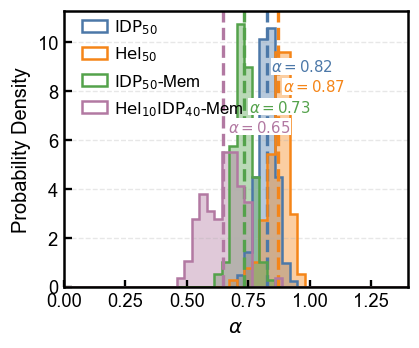

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

# ===================== 数据集配置 =====================
SCENARIO_COLORS = {
    "IDP_SOLV": "#4C78A8",
    "HELIX_SOLV": "#F58518",
    "IDP_MEM": "#54A24B",
    "HELIX_MEM": "#B279A2",
}

SCENARIOS = [
    {
        'label': r'$\text{IDP}_{50}$',
        'color': SCENARIO_COLORS["IDP_SOLV"],
        'msd_file': 'IDP_SOLV_msd_matrix.npy',
        'time_file': 'IDP_SOLV_time_ns.npy',
        'fit_range': (10.0, 100.0)
    },
    {
        'label': r'$\text{Hel}_{50}$',
        'color': SCENARIO_COLORS["HELIX_SOLV"],  
        'msd_file': 'Helix_SOLV_msd_matrix.npy',
        'time_file': 'Helix_SOLV_time_ns.npy',
        'fit_range': (10.0, 100.0)
    },
    {
        'label': r'$\text{IDP}_{50}$-Mem',
        'color': SCENARIO_COLORS["IDP_MEM"],  
        'msd_file': 'IDP_MEM_msd_matrix.npy',
        'time_file': 'IDP_MEM_time_ns.npy',
        'fit_range': (10.0, 100.0)
    },
    {
        'label': r'$\text{Hel}_{10}\text{IDP}_{40}$-Mem',
        'color': SCENARIO_COLORS["HELIX_MEM"], 
        'msd_file': 'Helix_MEM_msd_matrix.npy',
        'time_file': 'Helix_MEM_time_ns.npy',
        'fit_range': (10.0, 100.0)
    }
]

OUTPUT_PLOT = 'Combined_Alpha_Distribution.png'

# ===================== 计算函数 =====================

def calculate_alphas(msd_matrix, time_ns, fit_range):
    """
    计算给定 MSD 矩阵中每一列（每条链）的 Alpha 值
    """
    start_ns, end_ns = fit_range
    alphas = []
    
    # 找到时间窗口对应的索引
    fit_idx = (time_ns >= start_ns) & (time_ns <= end_ns)
    t_fit = time_ns[fit_idx]
    
    # 遍历每一条链
    for i in range(msd_matrix.shape[1]):
        msd_fit = msd_matrix[fit_idx, i]
        
        # 数据清洗：去除 NaN 和 非正值
        valid_mask = ~np.isnan(msd_fit) & (msd_fit > 0)
        
        if np.sum(valid_mask) > 2: # 至少需要几个点才能做拟合
            ln_t = np.log(t_fit[valid_mask])
            ln_msd = np.log(msd_fit[valid_mask])
            
            try:
                res = linregress(ln_t, ln_msd)
                alphas.append(res.slope)
            except ValueError:
                continue 
            
    return np.array(alphas)

# ===================== 绘图主程序 =====================

def main():
    fig, ax = new_figure(mode='single', height_mm=75)
    
    bins = np.linspace(0, 1.5, 50) 
    mean_annotations = []
    
    print(f"{'Label':<15} | {'Fit Range (ns)':<15} | {'Count':<8} | {'Mean Alpha':<10}")
    print("-" * 60)

    # 遍历每一个场景
    for sc in SCENARIOS:
        if not (os.path.exists(sc['msd_file']) and os.path.exists(sc['time_file'])):
            print(f"Warning: Files for {sc['label']} not found. Skipping.")
            continue
            
        msd_data = np.load(sc['msd_file'])
        time_data = np.load(sc['time_file'])
        
        alphas = calculate_alphas(msd_data, time_data, sc['fit_range'])
        
        if len(alphas) == 0:
            print(f"Warning: No valid alpha calculated for {sc['label']}.")
            continue

        mean_alpha = np.mean(alphas)
        
        print(f"{sc['label']:<15} | {str(sc['fit_range']):<15} | {len(alphas):<8} | {mean_alpha:.3f}")
        
        # 绘制半透明直方图
        ax.hist(alphas, bins=bins, color=sc['color'], alpha=0.4, 
                density=True, edgecolor=None, label=None)
        
        # 绘制轮廓线
        ax.hist(alphas, bins=bins, color=sc['color'], alpha=1.0, 
                density=True, histtype='step', linewidth=1.5, label=sc['label'])
        
        # 绘制均值虚线
        ax.axvline(mean_alpha, color=sc['color'], linestyle='--', linewidth=2)
        mean_annotations.append((mean_alpha, sc['color'], f"$\\alpha={mean_alpha:.2f}$"))
        
    # ===================== 图表修饰 (关键修复部分) =====================
    
    # 修复 1: 使用原始字符串 r'...' 避免 \alpha 被转义
    ax.set_xlabel(r'$\alpha$', fontsize=mpl.rcParams['axes.labelsize'])
    ax.set_ylabel('Probability Density', fontsize=mpl.rcParams['axes.labelsize'])
    
    # 修复 2: 同样使用 r'...'
    #ax.set_title(r'Comparison of Diffusion Exponents ($\alpha$)')
    
    ax.set_xlim(0, 1.4)
    y_min, y_max = ax.get_ylim()
    text_y_positions = np.linspace(y_max * 0.8, y_max * 0.58, len(mean_annotations))
    for (mean_alpha, color, text), y_text in zip(mean_annotations, text_y_positions):
        ax.text(
            mean_alpha + 0.02,
            y_text,
            text,
            color=color,
            fontsize=max(mpl.rcParams['legend.fontsize'] - 1, 7),
            ha='left',
            va='center',
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=0.4),
            zorder=6,
        )
    
    # 构建 Legend
    handles, labels = ax.get_legend_handles_labels()
    
    ax.legend(
        handles,
        labels,
        loc='upper left',
        bbox_to_anchor=(0.01, 1.03),
        bbox_transform=ax.transAxes,
        frameon=True,
        framealpha=0,
        facecolor='white',
        edgecolor='none',
        fontsize=mpl.rcParams['legend.fontsize'],
        handlelength=1.5,
    )
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout(pad=0.8)
    savefig_pub(fig, OUTPUT_PLOT, tight=False)
    print("\n" + "="*60)
    print(f"Plot saved to: {OUTPUT_PLOT}")
    plt.show()

if __name__ == "__main__":
    main()


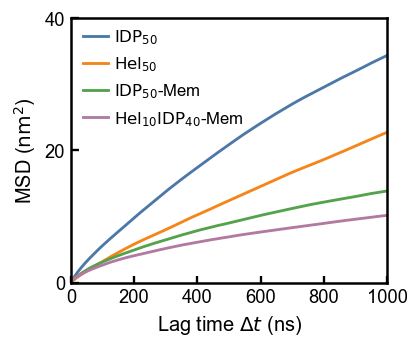

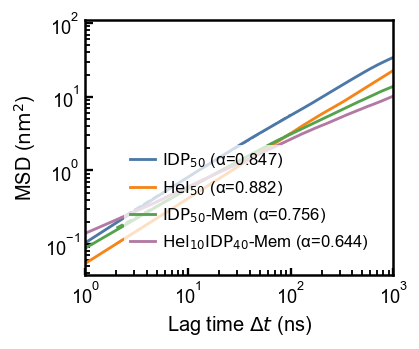

alpha 拟合区间: 2.0-100.0 ns
$\text{IDP}_{50}$ alpha = 0.8472
$\text{Hel}_{50}$ alpha = 0.8818
$\text{IDP}_{50}$-Mem alpha = 0.7562
$\text{Hel}_{10}\text{IDP}_{40}$-Mem alpha = 0.6444


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 4个体系对应的缓存文件（来自cell8-11），配色沿用 alpha 分布图 cell。
if "SCENARIO_COLORS" not in globals():
    SCENARIO_COLORS = {
        "IDP_SOLV": "#4C78A8",
        "HELIX_SOLV": "#F58518",
        "IDP_MEM": "#54A24B",
        "HELIX_MEM": "#B279A2",
    }

series_cfg = [
    ("IDP_SOLV", r"$\text{IDP}_{50}$", "IDP_SOLV_time_ns.npy", "IDP_SOLV_msd_matrix.npy"),
    ("HELIX_SOLV", r"$\text{Hel}_{50}$", "Helix_SOLV_time_ns.npy", "Helix_SOLV_msd_matrix.npy"),
    ("IDP_MEM", r"$\text{IDP}_{50}$-Mem", "IDP_MEM_time_ns.npy", "IDP_MEM_msd_matrix.npy"),
    ("HELIX_MEM", r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem", "Helix_MEM_time_ns.npy", "Helix_MEM_msd_matrix.npy"),
]

FIT_START_NS = 2.0
FIT_END_NS = 100.0
A2_TO_NM2 = 0.01

loaded = {}
for key, label, time_file, msd_file in series_cfg:
    if not (os.path.exists(time_file) and os.path.exists(msd_file)):
        print(f"[跳过] 缺少文件: {time_file} 或 {msd_file}")
        continue

    t = np.load(time_file)
    msd = np.load(msd_file)
    avg_msd = np.mean(msd, axis=1) * A2_TO_NM2
    loaded[label] = (t, avg_msd, SCENARIO_COLORS[key])

if len(loaded) < 2:
    raise RuntimeError("可用数据少于2组，无法做对比图。请先运行cell8-11生成缓存文件。")

# 取共同时间区间，避免不同轨迹长度导致的维度不一致
t_max_common = min(t[-1] for t, _, _ in loaded.values())
base_label = next(iter(loaded.keys()))
base_t = loaded[base_label][0]
common_t = base_t[base_t <= t_max_common]

# ---------------- 线性坐标：Average MSD 对比（x: 0-1000 ns） ----------------
fig_lin, ax_lin = new_figure(mode='single', height_mm=75)
for label, (t, y, color) in loaded.items():
    y_interp = np.interp(common_t, t, y)
    ax_lin.plot(common_t, y_interp, lw=1.7, color=color, label=label)

ax_lin.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
ax_lin.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
ax_lin.set_xlim(0, 1000)
ax_lin.set_ylim(0, 40)
ax_lin.set_yticks([0, 20, 40])
ax_lin.grid(False)
ax_lin.legend(
    loc='upper left',
    bbox_to_anchor=(-0.01, 1.02),
    bbox_transform=ax_lin.transAxes,
    frameon=True,
    framealpha=0,
    facecolor='white',
    edgecolor='none',
    fontsize=mpl.rcParams['legend.fontsize'],
    handlelength=1.5,
)
plt.tight_layout(pad=0.8)
savefig_pub(fig_lin, 'Average_MSD_compare_linear.png', tight=True)
plt.show()

# ---------------- Log-Log：alpha 对比（统一论文风格） ----------------
fig_log, ax_log = new_figure(mode='single', height_mm=75)
alpha_dict = {}

for label, (t, y, color) in loaded.items():
    y_interp = np.interp(common_t, t, y)

    fit_mask = (common_t >= FIT_START_NS) & (common_t <= FIT_END_NS) & (y_interp > 0)
    if np.sum(fit_mask) < 2:
        print(f"[警告] {label} 在拟合区间内有效点不足，跳过 alpha 拟合")
        continue

    ln_t = np.log(common_t[fit_mask])
    ln_y = np.log(y_interp[fit_mask])
    alpha, lnK = np.polyfit(ln_t, ln_y, 1)
    K = np.exp(lnK)
    alpha_dict[label] = alpha

    ax_log.loglog(common_t, y_interp, lw=1.7, color=color, label=f"{label} (α={alpha:.3f})")
    ax_log.loglog(common_t[fit_mask], K * (common_t[fit_mask] ** alpha), color=color, ls='--', lw=1.2)

ax = ax_log
ax.set_xlabel(r'Lag time $\mathit{\Delta}t$ (ns)', fontsize=mpl.rcParams['axes.labelsize'])
ax.set_ylabel(r'MSD ($\mathrm{nm^2}$)', fontsize=mpl.rcParams['axes.labelsize'])
ax.set_xlim(1, 1000)

# 四边框 + 无网格
ax.grid(False)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.tick_params(top=False, right=False)

ax.legend(
    loc='lower right',
    bbox_to_anchor=(0.97, 0.03),
    bbox_transform=ax.transAxes,
    frameon=True,
    framealpha=0.75,
    facecolor='white',
    edgecolor='none',
    fontsize=mpl.rcParams['legend.fontsize'],
    handlelength=1.5,
)
plt.tight_layout(pad=0.8)
savefig_pub(fig_log, 'Average_MSD_compare_loglog_alpha_nature.png', tight=True)
plt.show()

print(f"alpha 拟合区间: {FIT_START_NS}-{FIT_END_NS} ns")
for label, alpha in alpha_dict.items():
    print(f"{label:<10s} alpha = {alpha:.4f}")


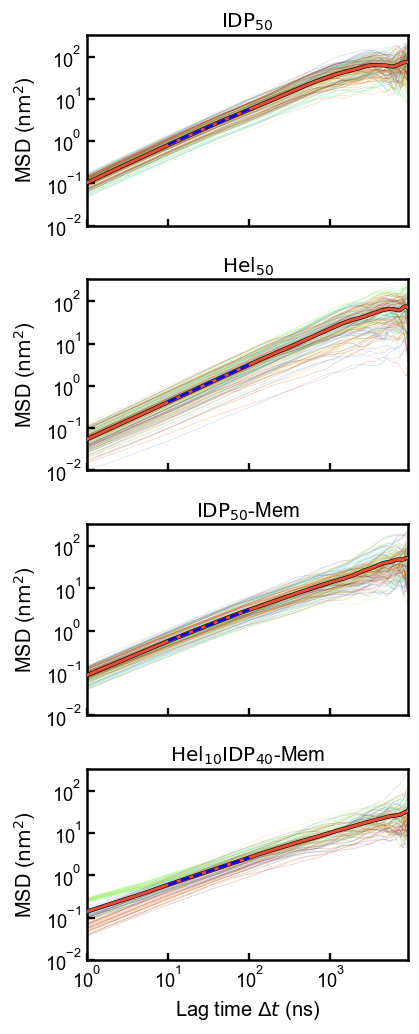

绘图完成: Raw_MSD_loglog_4x1.png


In [26]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullLocator

# 四个体系的原始 per-chain MSD log-log 图；只画原始曲线、平均线和拟合区间虚线，不做 alpha 文本注释。
RAW_SERIES_CFG = [
    (r"$\text{IDP}_{50}$", "IDP_SOLV_time_ns.npy", "IDP_SOLV_msd_matrix.npy"),
    (r"$\text{Hel}_{50}$", "Helix_SOLV_time_ns.npy", "Helix_SOLV_msd_matrix.npy"),
    (r"$\text{IDP}_{50}$-Mem", "IDP_MEM_time_ns.npy", "IDP_MEM_msd_matrix.npy"),
    (r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem", "Helix_MEM_time_ns.npy", "Helix_MEM_msd_matrix.npy"),
]

OUTPUT_RAW_LOGLOG = "Raw_MSD_loglog_4x1.png"
A2_TO_NM2 = 0.01
COLOR_MAP = "turbo"
FIT_START_NS = 10.0
FIT_END_NS = 100.0

loaded_raw = []
for label, time_file, msd_file in RAW_SERIES_CFG:
    if not (os.path.exists(time_file) and os.path.exists(msd_file)):
        print(f"[跳过] 缺少文件: {time_file} 或 {msd_file}")
        continue

    time_ns = np.load(time_file)
    msd_matrix_nm2 = np.load(msd_file) * A2_TO_NM2
    loaded_raw.append((label, time_ns, msd_matrix_nm2))

if len(loaded_raw) != len(RAW_SERIES_CFG):
    raise RuntimeError("四组原始 MSD 缓存未全部找到，请先运行前面生成缓存的 cell。")

set_pub_style()
fig, axes = plt.subplots(
    len(loaded_raw),
    1,
    figsize=(mm_to_inch(FIG_SIZE["single"]), mm_to_inch(55 * len(loaded_raw))),
    sharex=True,
)
fig.subplots_adjust(hspace=0.32)

x_min = min(time_ns[0] for _, time_ns, _ in loaded_raw)
x_max = max(time_ns[-1] for _, time_ns, _ in loaded_raw)

all_positive = np.concatenate([
    msd_matrix_nm2[msd_matrix_nm2 > 0]
    for _, _, msd_matrix_nm2 in loaded_raw
])
y_min = max(all_positive.min() * 0.8, 1e-2)
y_max = all_positive.max() * 1.2

for ax, (label, time_ns, msd_matrix_nm2) in zip(axes, loaded_raw):
    n_chains = msd_matrix_nm2.shape[1]
    cmap = plt.get_cmap(COLOR_MAP)
    colors = cmap(np.linspace(0, 1, n_chains))

    for chain_idx in range(n_chains):
        ax.loglog(
            time_ns,
            msd_matrix_nm2[:, chain_idx],
            color=colors[chain_idx],
            lw=0.4,
            alpha=0.25,
            zorder=1,
        )

    avg_msd_nm2 = np.mean(msd_matrix_nm2, axis=1)
    ax.loglog(time_ns, avg_msd_nm2, color="black", lw=2.5, zorder=3)
    ax.loglog(time_ns, avg_msd_nm2, color="#E64B35", lw=1.8, zorder=4)

    fit_mask = (time_ns >= FIT_START_NS) & (time_ns <= FIT_END_NS) & (avg_msd_nm2 > 0)
    if np.sum(fit_mask) >= 2:
        alpha, lnK = np.polyfit(np.log(time_ns[fit_mask]), np.log(avg_msd_nm2[fit_mask]), 1)
        ax.loglog(
            time_ns[fit_mask],
            np.exp(lnK) * (time_ns[fit_mask] ** alpha),
            color="blue",
            ls="--",
            lw=1.5,
            zorder=5,
        )
    else:
        print(f"[警告] {label} 在 {FIT_START_NS}-{FIT_END_NS} ns 内有效拟合点不足。")

    ax.set_title(label, fontsize=mpl.rcParams["axes.titlesize"], pad=4)
    ax.set_ylabel(r"MSD ($\mathrm{nm^2}$)", fontsize=mpl.rcParams["axes.labelsize"])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)
    ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.tick_params(top=False, right=False)

axes[-1].set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)", fontsize=mpl.rcParams["axes.labelsize"])

plt.tight_layout(pad=0.8, h_pad=0.8)
savefig_pub(fig, OUTPUT_RAW_LOGLOG, tight=True)
plt.show()
print(f"绘图完成: {OUTPUT_RAW_LOGLOG}")


[缓存] 直接读取: IDP_SOLV_NTer_NAC_CTer_msd_avg.npz
[缓存] 直接读取: HELIX_SOLV_NTer_NAC_CTer_msd_avg.npz
[缓存] 直接读取: IDP_MEM_NTer_NAC_CTer_msd_avg.npz
[缓存] 直接读取: HELIX_MEM_NTer_NAC_CTer_msd_avg.npz
有效链数统计:
$\text{IDP}_{50}$: N = 139
$\text{Hel}_{50}$: N = 133
$\text{IDP}_{50}$-Mem: N = 131
$\text{Hel}_{10}\text{IDP}_{40}$-Mem: N = 95


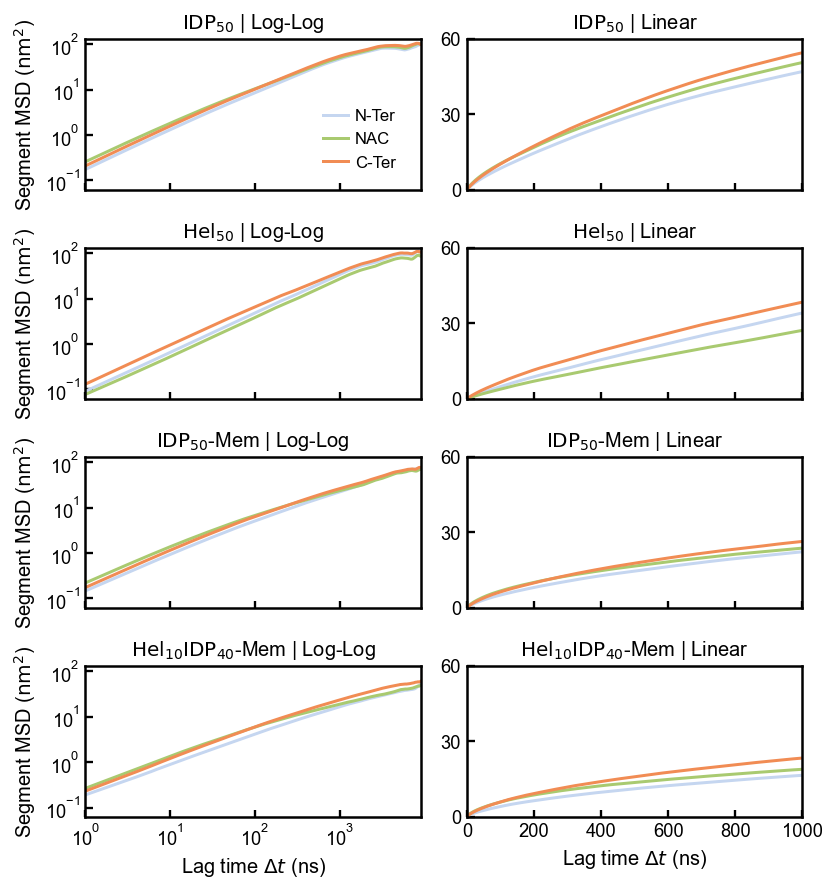

绘图完成: segment_MSD_3segment_log_linear.png


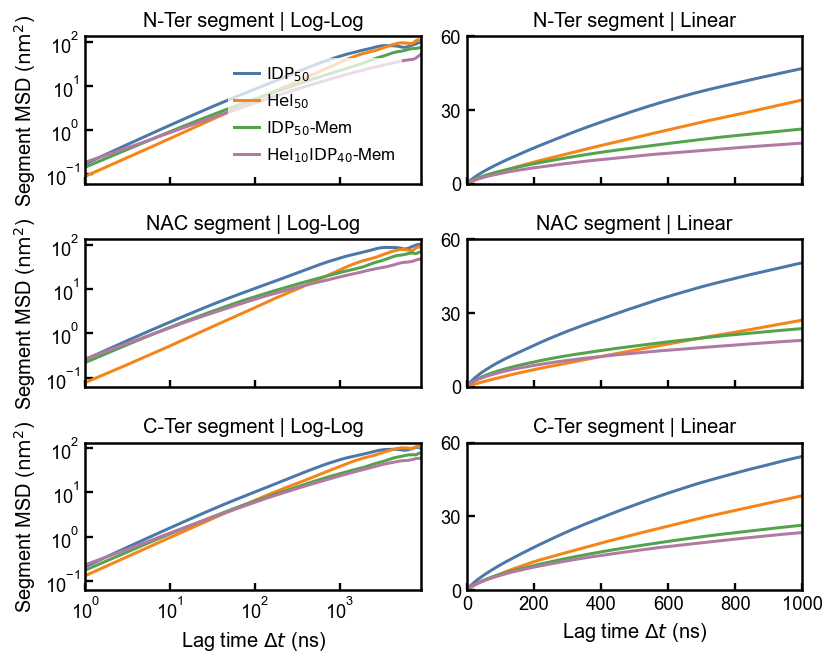

绘图完成: segment_MSD_crossgroup_3segment_log_linear.png


In [27]:
import os
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

try:
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import capped_distance
    HAS_MDA = True
    MDA_IMPORT_ERROR = None
except Exception as exc:
    HAS_MDA = False
    MDA_IMPORT_ERROR = exc

# 3 个片段：N-Ter (1-60), NAC (61-95), C-Ter (96-140)
SEGMENTS = [
    {"key": "NTer", "label": "N-Ter", "start": 1, "end": 60},
    {"key": "NAC", "label": "NAC", "start": 61, "end": 95},
    {"key": "CTer", "label": "C-Ter", "start": 96, "end": 140},
]

# 参数与范围对应当前前序分析单元，体系配色沿用 alpha 分布图 cell。
if "SCENARIO_COLORS" not in globals():
    SCENARIO_COLORS = {
        "IDP_SOLV": "#4C78A8",
        "HELIX_SOLV": "#F58518",
        "IDP_MEM": "#54A24B",
        "HELIX_MEM": "#B279A2",
    }

DATASETS = [
    {
        "name": "IDP_SOLV",
        "title": r"$\text{IDP}_{50}$",
        "color": SCENARIO_COLORS["IDP_SOLV"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {
            "RESIDUES_PER_CHAIN": 140,
            "BB_SELECTION_STR": "name BB",
            "ANALYSIS_CHAIN_RANGE": (0, None),
            "START_FRAME": 10000,
            "END_FRAME": -1,
            "STRIDE": 1,
            "CLUSTER_DIST_CUTOFF": 8.0,
            "MAX_LAG_RATIO": 0.9,
        },
        "cache": "IDP_SOLV_NTer_NAC_CTer_msd_avg.npz",
    },
    {
        "name": "HELIX_SOLV",
        "title": r"$\text{Hel}_{50}$",
        "color": SCENARIO_COLORS["HELIX_SOLV"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {
            "RESIDUES_PER_CHAIN": 140,
            "BB_SELECTION_STR": "name BB",
            "ANALYSIS_CHAIN_RANGE": (0, None),
            "START_FRAME": 10000,
            "END_FRAME": -1,
            "STRIDE": 1,
            "CLUSTER_DIST_CUTOFF": 8.0,
            "MAX_LAG_RATIO": 0.9,
        },
        "cache": "HELIX_SOLV_NTer_NAC_CTer_msd_avg.npz",
    },
    {
        "name": "IDP_MEM",
        "title": r"$\text{IDP}_{50}$-Mem",
        "color": SCENARIO_COLORS["IDP_MEM"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus2/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_0_plus3/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {
            "RESIDUES_PER_CHAIN": 140,
            "BB_SELECTION_STR": "name BB",
            "ANALYSIS_CHAIN_RANGE": (0, None),
            "START_FRAME": 0,
            "END_FRAME": -1,
            "STRIDE": 1,
            "CLUSTER_DIST_CUTOFF": 8.0,
            "MAX_LAG_RATIO": 0.9,
        },
        "cache": "IDP_MEM_NTer_NAC_CTer_msd_avg.npz",
    },
    {
        "name": "HELIX_MEM",
        "title": r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem",
        "color": SCENARIO_COLORS["HELIX_MEM"],
        "replicates": [
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL2/TR_Mdvwhole/clus_centered.xtc",
            ),
            (
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/pbc.tpr",
                "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL3/TR_Mdvwhole/clus_centered.xtc",
            ),
        ],
        "params": {
            "RESIDUES_PER_CHAIN": 140,
            "BB_SELECTION_STR": "name BB",
            "ANALYSIS_CHAIN_RANGE": (-40, None),
            "START_FRAME": 10000,
            "END_FRAME": -1,
            "STRIDE": 1,
            "CLUSTER_DIST_CUTOFF": 8.0,
            "MAX_LAG_RATIO": 0.9,
        },
        "cache": "HELIX_MEM_NTer_NAC_CTer_msd_avg.npz",
    },
]

SEGMENT_COLORS = {
    "NTer": "#C5D6F0",
    "NAC": "#A9CA70",
    "CTer": "#F18C54",
}

OUTPUT_WITHIN = "segment_MSD_3segment_log_linear.png"
OUTPUT_CROSS = "segment_MSD_crossgroup_3segment_log_linear.png"
A2_TO_NM2 = 0.01


def apply_plot_style():
    set_pub_style()


def style_axis(ax, scale="linear"):
    ax.tick_params(top=False, right=False)
    ax.grid(False)

    if scale == "log":
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax.yaxis.set_major_locator(LogLocator(base=10, numticks=5))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
    else:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.minorticks_off()


def annotate_panel(ax, text):
    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=mpl.rcParams['legend.fontsize'],
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5),
    )


def build_segment_groups(protein, residues_per_chain, segments):
    total_residues = len(protein.residues)
    if total_residues % residues_per_chain != 0:
        raise ValueError(
            f"Protein residue count ({total_residues}) is not divisible by {residues_per_chain}."
        )

    n_chains = total_residues // residues_per_chain
    segment_groups = []
    for chain_idx in range(n_chains):
        chain_start = chain_idx * residues_per_chain
        chain_groups = []
        for segment in segments:
            atom_group = protein.residues[
                chain_start + segment["start"] - 1 : chain_start + segment["end"]
            ].atoms
            if len(atom_group) == 0:
                raise ValueError(
                    f"Empty atom selection for chain {chain_idx} segment {segment['label']}."
                )
            chain_groups.append(atom_group)
        segment_groups.append(chain_groups)
    return n_chains, segment_groups


def process_single_replicate(args):
    rep_id, top_file, traj_file, dataset = args
    params = dataset["params"]

    if not HAS_MDA:
        return None, f"MDAnalysis unavailable: {MDA_IMPORT_ERROR}"

    try:
        u = mda.Universe(top_file, traj_file)
    except Exception as exc:
        return None, f"{os.path.basename(traj_file)}: {exc}"

    protein = u.select_atoms("protein")
    try:
        n_chains, segment_groups = build_segment_groups(
            protein, params["RESIDUES_PER_CHAIN"], SEGMENTS
        )
    except Exception as exc:
        return None, f"{os.path.basename(traj_file)}: {exc}"

    n_atoms_per_chain = len(protein) // n_chains
    bb_atoms = protein.select_atoms(params["BB_SELECTION_STR"])
    bb_to_chain = (bb_atoms.indices - protein.indices[0]) // n_atoms_per_chain

    traj_slice = u.trajectory[
        params["START_FRAME"] : params["END_FRAME"] : params["STRIDE"]
    ]
    n_frames = len(traj_slice)
    if n_frames < 2:
        return None, f"{os.path.basename(traj_file)}: not enough frames after slicing."

    segment_centers = np.zeros(
        (n_frames, n_chains, len(SEGMENTS), 3),
        dtype=np.float32,
    )

    start_c, end_c = params["ANALYSIS_CHAIN_RANGE"]
    end_c = n_chains if end_c is None else end_c
    valid_mask = np.zeros(n_chains, dtype=bool)
    valid_mask[start_c:end_c] = True

    for frame_idx, ts in enumerate(traj_slice):
        for chain_idx, chain_groups in enumerate(segment_groups):
            for seg_idx, atom_group in enumerate(chain_groups):
                segment_centers[frame_idx, chain_idx, seg_idx] = atom_group.positions.mean(axis=0)

        pairs = capped_distance(
            bb_atoms.positions,
            bb_atoms.positions,
            max_cutoff=params["CLUSTER_DIST_CUTOFF"],
            box=ts.dimensions,
            return_distances=False,
        )
        c_pairs = bb_to_chain[pairs]
        c_pairs = c_pairs[c_pairs[:, 0] != c_pairs[:, 1]]

        if len(c_pairs) > 0:
            rows = np.concatenate([c_pairs[:, 0], c_pairs[:, 1]])
            cols = np.concatenate([c_pairs[:, 1], c_pairs[:, 0]])
            data = np.ones(len(rows), dtype=np.int8)
            adj = csr_matrix((data, (rows, cols)), shape=(n_chains, n_chains))
        else:
            adj = csr_matrix((n_chains, n_chains))

        n_comp, labels = connected_components(adj, directed=False)
        if n_comp > 0:
            max_label = np.argmax(np.bincount(labels))
            valid_mask &= labels == max_label
        else:
            valid_mask[:] = False
            break

    final_indices = np.where(valid_mask)[0]
    if len(final_indices) == 0:
        return None, f"{os.path.basename(traj_file)}: no chains remained in the dominant cluster."

    max_lag = min(int(n_frames * params["MAX_LAG_RATIO"]), n_frames - 1)
    if max_lag < 1:
        return None, f"{os.path.basename(traj_file)}: max lag is smaller than 1."

    segment_msds = {}
    for seg_idx, segment in enumerate(SEGMENTS):
        valid_centers = segment_centers[:, final_indices, seg_idx, :]
        msd_matrix = np.zeros((max_lag, len(final_indices)), dtype=np.float32)
        for lag in range(1, max_lag + 1):
            diff = valid_centers[lag:] - valid_centers[:-lag]
            msd_matrix[lag - 1] = np.mean(np.sum(diff * diff, axis=2), axis=0)
        segment_msds[segment["key"]] = msd_matrix

    time_ns = (
        np.arange(1, max_lag + 1, dtype=np.float32)
        * u.trajectory.dt
        * params["STRIDE"]
        / 1000.0
    )
    return {
        "segment_msds": segment_msds,
        "time_ns": time_ns,
        "count": len(final_indices),
        "file": os.path.basename(traj_file),
    }, None


def analyze_dataset(dataset):
    cache_file = dataset["cache"]
    if os.path.exists(cache_file):
        cache = np.load(cache_file)
        print(f"[缓存] 直接读取: {cache_file}")
        return {
            "time_ns": cache["time_ns"],
            "avg_msds": {segment["key"]: cache[f"avg_{segment['key']}"] for segment in SEGMENTS},
            "total_count": int(cache["total_count"]),
        }

    if not HAS_MDA:
        raise RuntimeError(
            f"未找到缓存且 MDAnalysis 不可用，无法计算 {dataset['title']}。原始错误: {MDA_IMPORT_ERROR}"
        )

    print(f"[计算] 未找到缓存，开始计算: {dataset['title']}")
    tasks = [(idx, top, traj, dataset) for idx, (top, traj) in enumerate(dataset["replicates"])]
    max_workers = min(len(tasks), os.cpu_count() or 1)
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_single_replicate, tasks))

    print(f"\n{'=' * 80}")
    print(dataset["title"])
    print(f"{'replicate':<10} | {'trajectory':<35} | {'valid chains':<12} | status")
    print("-" * 80)

    segment_blocks = {segment["key"]: [] for segment in SEGMENTS}
    ref_time_ns = None
    total_count = 0
    for rep_idx, (res, err) in enumerate(results):
        if res is None:
            print(f"{rep_idx:<10} | {'-':<35} | {0:<12} | {err}")
            continue

        print(f"{rep_idx:<10} | {res['file']:<35} | {res['count']:<12} | OK")
        total_count += res["count"]
        if ref_time_ns is None:
            ref_time_ns = res["time_ns"]
        for segment in SEGMENTS:
            segment_blocks[segment["key"]].append(res["segment_msds"][segment["key"]])

    if ref_time_ns is None:
        raise RuntimeError(f"{dataset['title']}: no valid replicate data found.")

    avg_msds = {}
    for segment in SEGMENTS:
        key = segment["key"]
        if not segment_blocks[key]:
            raise RuntimeError(f"{dataset['title']}: segment {segment['label']} has no valid data.")
        combined = np.hstack(segment_blocks[key])
        avg_msds[key] = combined.mean(axis=1)

    np.savez(
        cache_file,
        time_ns=ref_time_ns,
        total_count=total_count,
        **{f"avg_{segment['key']}": avg_msds[segment["key"]] for segment in SEGMENTS},
    )
    print(f"[缓存] 已保存: {cache_file}")

    return {
        "time_ns": ref_time_ns,
        "avg_msds": avg_msds,
        "total_count": total_count,
    }


# ===================== 主流程：有缓存直接画；无缓存先算再画 =====================
results = [analyze_dataset(dataset) for dataset in DATASETS]

loaded = []
for dataset, result in zip(DATASETS, results):
    loaded.append(
        {
            "name": dataset["name"],
            "title": dataset["title"],
            "color": dataset["color"],
            "time_ns": result["time_ns"],
            "avg_msds": {key: value * A2_TO_NM2 for key, value in result["avg_msds"].items()},
            "total_count": result["total_count"],
        }
    )

if len(loaded) < 2:
    raise RuntimeError("可用体系少于2个，无法画并排 log/linear 对比图。")

print("有效链数统计:")
for item in loaded:
    print(f"{item['title']}: N = {item['total_count']}")

x_min_log = min(item["time_ns"][0] for item in loaded)
x_max = max(item["time_ns"][-1] for item in loaded)
x_max_linear = min(1000.0, x_max)

# 全局 y 范围（log）
all_pos = []
for item in loaded:
    for seg in SEGMENTS:
        y = item["avg_msds"][seg["key"]]
        all_pos.append(y[y > 0])

non_empty_pos = [arr for arr in all_pos if arr.size > 0]
if not non_empty_pos:
    raise RuntimeError("所有片段的 MSD 都不大于 0，无法绘制 log-log 图。")

all_pos = np.concatenate(non_empty_pos)
y_min_log = all_pos.min() * 0.8
y_max_log = all_pos.max() * 1.2

apply_plot_style()

row_height = mm_to_inch(48)
fig_width = mm_to_inch(FIG_SIZE["double"])

# ============================================================
# 图A：同组内不同片段（每行一个体系：左log 右linear）
# ============================================================
figA, axesA = plt.subplots(
    len(loaded),
    2,
    figsize=(fig_width, row_height * len(loaded)),
    squeeze=False,
    sharex='col',
)

for i, item in enumerate(loaded):
    ax_log = axesA[i, 0]
    ax_lin = axesA[i, 1]

    for seg in SEGMENTS:
        y = item["avg_msds"][seg["key"]]
        label = seg["label"]
        ax_log.loglog(item["time_ns"], y, lw=1.8, color=SEGMENT_COLORS[seg["key"]], label=label)
        ax_lin.plot(item["time_ns"], y, lw=1.8, color=SEGMENT_COLORS[seg["key"]], label=label)

    ax_log.set_title(f"{item['title']} | Log-Log")
    ax_lin.set_title(f"{item['title']} | Linear")

    ax_log.set_xlim(x_min_log, x_max)
    ax_log.set_ylim(y_min_log, y_max_log)
    ax_lin.set_xlim(0, x_max_linear)
    ax_lin.set_ylim(0, 60)

    style_axis(ax_log, scale="log")
    style_axis(ax_lin, scale="linear")
    ax_lin.set_yticks([0, 30, 60])

    ax_log.set_ylabel(r"Segment MSD ($\mathrm{nm^2}$)")

axesA[-1, 0].set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")
axesA[-1, 1].set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")

handles_seg, labels_seg = axesA[0, 0].get_legend_handles_labels()
axesA[0, 0].legend(
    handles_seg,
    labels_seg,
    loc="lower right",
    bbox_to_anchor=(0.97, 0.03),
    bbox_transform=axesA[0, 0].transAxes,
    frameon=True,
    framealpha=0.75,
    facecolor="white",
    edgecolor="none",
    handlelength=1.5,
)
figA.tight_layout()
savefig_pub(figA, OUTPUT_WITHIN, tight=True)
plt.show()
print(f"绘图完成: {OUTPUT_WITHIN}")

# ============================================================
# 图B：不同组同一片段（每行一个片段：左log 右linear）
# ============================================================
figB, axesB = plt.subplots(
    len(SEGMENTS),
    2,
    figsize=(fig_width, row_height * len(SEGMENTS)),
    squeeze=False,
    sharex='col',
)

for i, seg in enumerate(SEGMENTS):
    ax_log = axesB[i, 0]
    ax_lin = axesB[i, 1]

    for item in loaded:
        label = item["title"]
        y = item["avg_msds"][seg["key"]]
        ax_log.loglog(item["time_ns"], y, lw=1.8, color=item["color"], label=label)
        ax_lin.plot(item["time_ns"], y, lw=1.8, color=item["color"], label=label)

    ax_log.set_title(f"{seg['label']} segment | Log-Log")
    ax_lin.set_title(f"{seg['label']} segment | Linear")

    ax_log.set_xlim(x_min_log, x_max)
    ax_log.set_ylim(y_min_log, y_max_log)
    ax_lin.set_xlim(0, x_max_linear)
    ax_lin.set_ylim(0, 60)

    style_axis(ax_log, scale="log")
    style_axis(ax_lin, scale="linear")
    ax_lin.set_yticks([0, 30, 60])
    ax_log.set_ylabel(r"Segment MSD ($\mathrm{nm^2}$)")

axesB[-1, 0].set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")
axesB[-1, 1].set_xlabel(r"Lag time $\mathit{\Delta}t$ (ns)")

handles_ds, labels_ds = axesB[0, 0].get_legend_handles_labels()
axesB[0, 0].legend(
    handles_ds,
    labels_ds,
    loc="lower right",
    bbox_to_anchor=(0.97, 0.03),
    bbox_transform=axesB[0, 0].transAxes,
    frameon=True,
    framealpha=0.75,
    facecolor="white",
    edgecolor="none",
    handlelength=1.5,
)
figB.tight_layout()
savefig_pub(figB, OUTPUT_CROSS, tight=True)
plt.show()
print(f"绘图完成: {OUTPUT_CROSS}")
